# High-freq bouts — clean computational pipeline

Mirror of `alarm_bouts_2.ipynb` but for `event_type == "high-freq"`.
Top half builds reusable DataFrames once; later cells slice them.

After the load + bout-detection cell, every row in `hf` carries:
- `bout_id` — unique per consecutive run within `(date_folder, exp, assigned_location)`, gap ≤ `ICI_HIGH_FREQ_BOUT_THRESHOLD_S`.
- `bout_size` — total calls in that bout (broadcast to every row).
- `position` — chronological position within the bout (1 = first call).

## Setup

In [1]:
# === Cell: setup ===
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PARQUET_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")
FIGURES_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/high_freq")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]
ICI_HIGH_FREQ_BOUT_THRESHOLD_S = 0.2   # silent gap up to this counts as same bout
MIN_BOUT_SIZE = 2                      # bouts_meta keeps only bouts with >= this many calls

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")

## Load high-freq calls with bout annotations

In [2]:
# === Cell: load_high_freq_and_detect_bouts ===
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"] == "high-freq"]
    parts.append(df_d)
hf = pd.concat(parts, ignore_index=True)

hf = hf.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

prev_stop = hf.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
gaps = hf["start_time_real"] - prev_stop
is_new_bout = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_HIGH_FREQ_BOUT_THRESHOLD_S))

hf["bout_id"]   = is_new_bout.cumsum()
hf["bout_size"] = hf.groupby("bout_id")["bout_id"].transform("size")
hf["position"]  = hf.groupby("bout_id").cumcount() + 1

print(f"{len(hf):,} high-freq calls in {hf['bout_id'].nunique():,} bouts")
hf.head(10)

448,089 high-freq calls in 315,640 bouts


,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,...,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment,bout_id,bout_size,position
0,235,0,high-freq,224.108928,224.154872,0.045944,arena_1,10,0.000000,0.054327,...,0.244462,224.108928,224.154872,2025-03-21 19:38:34.108928,2025-03-21 19:38:34.154872,2025_03,1,1,1,1
1,235,0,high-freq,225.018368,225.048440,0.030072,arena_1,10,0.000000,0.007981,...,0.407156,225.018368,225.048440,2025-03-21 19:38:35.018368,2025-03-21 19:38:35.048440,2025_03,1,2,1,1
2,235,0,high-freq,242.768640,242.818936,0.050296,arena_1,10,0.000000,0.029809,...,0.324752,242.768640,242.818936,2025-03-21 19:38:52.768640,2025-03-21 19:38:52.818936,2025_03,1,3,1,1
3,235,0,high-freq,243.246720,243.266040,0.019320,arena_1,10,0.000000,0.032052,...,0.159627,243.246720,243.266040,2025-03-21 19:38:53.246720,2025-03-21 19:38:53.266040,2025_03,1,4,1,1
4,235,0,high-freq,328.354944,328.379896,0.024952,arena_1,10,0.000000,0.015059,...,0.351630,328.354944,328.379896,2025-03-21 19:40:18.354944,2025-03-21 19:40:18.379896,2025_03,1,5,1,1
5,235,1,high-freq,57.591552,57.622776,0.031224,arena_1,10,0.079810,0.031856,...,0.329037,417.591552,417.622776,2025-03-21 19:41:47.591552,2025-03-21 19:41:47.622776,2025_03,1,6,2,1
6,235,1,high-freq,57.753472,57.779584,0.026112,arena_1,10,0.009804,0.049575,...,0.222388,417.753472,417.779584,2025-03-21 19:41:47.753472,2025-03-21 19:41:47.779584,2025_03,1,6,2,2
7,235,1,high-freq,81.456768,81.478136,0.021368,arena_1,10,0.005990,0.009895,...,0.299959,441.456768,441.478136,2025-03-21 19:42:11.456768,2025-03-21 19:42:11.478136,2025_03,1,7,1,1
8,235,1,high-freq,82.037760,82.107384,0.069624,arena_1,10,0.031254,0.052377,...,0.233359,442.037760,442.107384,2025-03-21 19:42:12.037760,2025-03-21 19:42:12.107384,2025_03,1,8,4,1
9,235,1,high-freq,82.281344,82.304376,0.023032,arena_1,10,0.005557,0.020252,...,0.333506,442.281344,442.304376,2025-03-21 19:42:12.281344,2025-03-21 19:42:12.304376,2025_03,1,8,4,2


## Inter-call silent gap

Per-call silent gap = `this.start - prev.stop` within `(date_folder, exp, assigned_location)`.
Used to decide `ICI_HIGH_FREQ_BOUT_THRESHOLD_S`. Plotted on a log time axis with shared bins per date so the panels are comparable.

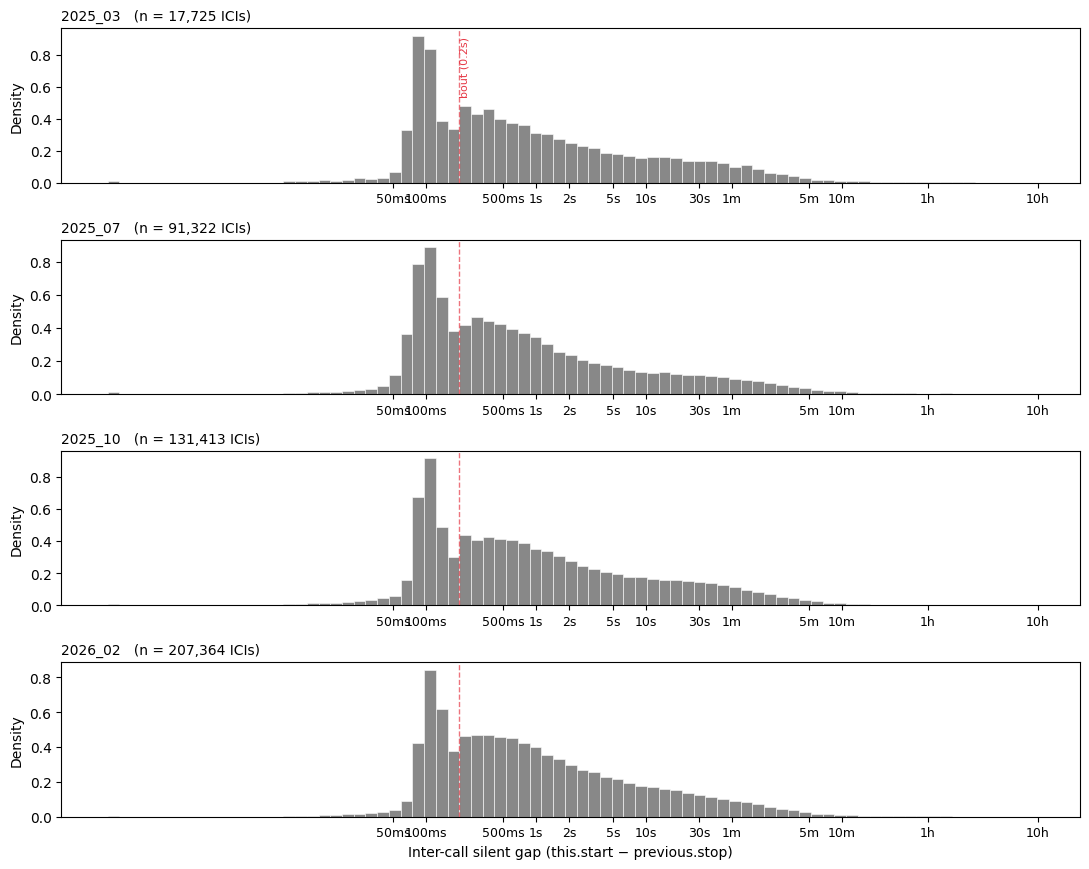

In [3]:
# === Cell: plot_ici_distribution_per_date ===
prev_stop = hf.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
hf_ici = pd.DataFrame({
    "date_folder": hf["date_folder"],
    "ici_s":       (hf["start_time_real"] - prev_stop).dt.total_seconds(),
}).dropna()
hf_ici = hf_ici[hf_ici["ici_s"] > 0]

# Shared log-bins so panels are comparable.
log_ici_all = np.log10(hf_ici["ici_s"])
bins = np.linspace(log_ici_all.min(), log_ici_all.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = hf_ici[hf_ici["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no ICIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    log_sub = np.log10(sub["ici_s"])
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)

    ax.axvline(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} ICIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=True)

# Tick labels on every panel.
tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[0].text(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), axes[0].get_ylim()[1] * 0.95,
             f"  bout ({ICI_HIGH_FREQ_BOUT_THRESHOLD_S}s)",
             rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Inter-call silent gap (this.start − previous.stop)")
fig.tight_layout()
save_fig(fig, "high_freq_ici_distribution_per_date")
plt.show()

## Sanity check: high-freq vs warble overlap

If the segmentation is mixing the two classes, merging them and recomputing
ICI should: (1) preserve the ~100ms within-bout mode, and (2) show the same
peak for cross-class transitions (HF→W, W→HF) as for same-class transitions
(HF→HF, W→W). If the classes are genuinely distinct, cross-class transitions
should sit at longer ICIs.

In [ ]:
# === Cell: load_hf_warble_merged ===
# Load high-freq + warble together, sort, compute silent gap and prev event_type.
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"].isin(["high-freq", "warble"])]
    parts.append(df_d)
hf_w = pd.concat(parts, ignore_index=True)

hf_w = hf_w.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

grp = hf_w.groupby(["date_folder", "exp", "assigned_location"])
prev_stop = grp["stop_time_real"].shift(1)
prev_type = grp["event_type"].shift(1)

hf_w["ici_s"]      = (hf_w["start_time_real"] - prev_stop).dt.total_seconds()
hf_w["prev_type"]  = prev_type
hf_w["transition"] = prev_type.fillna("none") + "->" + hf_w["event_type"]

# Drop first-of-group rows and any non-positive gaps.
hf_w_ici = hf_w.dropna(subset=["ici_s", "prev_type"])
hf_w_ici = hf_w_ici[hf_w_ici["ici_s"] > 0]

print(f"{len(hf_w):,} HF+W calls, {len(hf_w_ici):,} ICIs")
print("\nTransition counts (pooled):")
print(hf_w_ici["transition"].value_counts())

In [ ]:
# === Cell: plot_pooled_ici_hf_only_vs_merged ===
# Pooled ICI per date: HF-only vs (HF + warble) merged.
hf_only_ici = hf_ici  # already computed above
log_min = min(np.log10(hf_only_ici["ici_s"].min()), np.log10(hf_w_ici["ici_s"].min()))
log_max = max(np.log10(hf_only_ici["ici_s"].max()), np.log10(hf_w_ici["ici_s"].max()))
bins = np.linspace(log_min, log_max, 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.4 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    a = hf_only_ici[hf_only_ici["date_folder"] == date_tag]["ici_s"]
    b = hf_w_ici[hf_w_ici["date_folder"] == date_tag]["ici_s"]
    if a.empty or b.empty:
        ax.set_axis_off()
        continue
    ax.hist(np.log10(a), bins=bins, density=True,
            histtype="step", color="#1D3557", linewidth=1.4,
            label=f"high-freq only (n={len(a):,})")
    ax.hist(np.log10(b), bins=bins, density=True,
            histtype="step", color="#E63946", linewidth=1.4,
            label=f"high-freq + warble (n={len(b):,})")

    ax.axvline(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelbottom=True)

tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel("Inter-call silent gap")
fig.tight_layout()
save_fig(fig, "high_freq_vs_hf_plus_warble_ici_per_date")
plt.show()

In [ ]:
# === Cell: plot_transition_stratified_ici ===
# Transition-stratified ICI: four overlaid histograms per date.
TRANSITIONS = [
    ("high-freq->high-freq", "#1D3557"),
    ("warble->warble",       "#2A9D8F"),
    ("high-freq->warble",    "#E63946"),
    ("warble->high-freq",    "#F4A261"),
]

log_ici_all = np.log10(hf_w_ici["ici_s"])
bins = np.linspace(log_ici_all.min(), log_ici_all.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.6 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = hf_w_ici[hf_w_ici["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue
    for tlabel, color in TRANSITIONS:
        s = sub[sub["transition"] == tlabel]["ici_s"]
        if s.empty:
            continue
        ax.hist(np.log10(s), bins=bins, density=True,
                histtype="step", color=color, linewidth=1.4,
                label=f"{tlabel} (n={len(s):,})")

    ax.axvline(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(labelbottom=True)

tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel("Inter-call silent gap")
fig.tight_layout()
save_fig(fig, "ici_by_transition_per_date")
plt.show()

## Suspect-warble check

A "warble" flanked on both sides by high-freq calls with both ICIs ≤
`SUSPECT_ICI_S` is a candidate misclassification. If those calls had a high
`meanprob_high_freq`, the classifier was nearly choosing high-freq for them
— smoking gun for label flips inside fast HF sequences.

In [ ]:
# === Cell: suspect_warble_check ===
SUSPECT_ICI_S = 0.15   # max gap on both sides for a warble to count as "suspect"

# Forward-shift (within group) to get the next call's type and the gap from this.stop to next.start.
grp = hf_w.groupby(["date_folder", "exp", "assigned_location"])
hf_w["next_type"]   = grp["event_type"].shift(-1)
hf_w["next_ici_s"]  = grp["ici_s"].shift(-1)

is_warble = hf_w["event_type"] == "warble"
flanked   = (hf_w["prev_type"] == "high-freq") & (hf_w["next_type"] == "high-freq")
tight     = (hf_w["ici_s"] <= SUSPECT_ICI_S) & (hf_w["next_ici_s"] <= SUSPECT_ICI_S)

suspect_mask = is_warble & flanked & tight
hf_w["suspect_warble"] = suspect_mask

# Per-date counts and fractions.
warbles_per_date  = hf_w[is_warble].groupby("date_folder").size().rename("n_warbles")
suspects_per_date = hf_w[suspect_mask].groupby("date_folder").size().rename("n_suspect")
summary = pd.concat([warbles_per_date, suspects_per_date], axis=1).fillna(0).astype(int)
summary["fraction"] = (summary["n_suspect"] / summary["n_warbles"]).round(4)
print(f"=== Suspect warbles (flanked by HF, both ICIs <= {SUSPECT_ICI_S*1000:.0f}ms) ===")
print(summary.to_string())

# Compare meanprob distributions: suspect warbles vs all other warbles.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
warb_other   = hf_w[is_warble & ~suspect_mask]
warb_suspect = hf_w[suspect_mask]

bins = np.linspace(0, 1, 40)
for ax, col, title in [
    (axes[0], "meanprob_high_freq", "P(high-freq) for warble calls"),
    (axes[1], "meanprob_warble",    "P(warble) for warble calls"),
]:
    ax.hist(warb_other[col],   bins=bins, density=True, color="#888888",
            alpha=0.6, label=f"other warbles (n={len(warb_other):,})")
    ax.hist(warb_suspect[col], bins=bins, density=True, color="#E63946",
            alpha=0.6, label=f"suspect warbles (n={len(warb_suspect):,})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle(f"Suspect = warble flanked by HF with both ICIs <= {SUSPECT_ICI_S*1000:.0f}ms",
             fontsize=11)
fig.tight_layout()
save_fig(fig, "suspect_warble_meanprob")
plt.show()

## Merged HF+W bouts

Apply the same `ICI_HIGH_FREQ_BOUT_THRESHOLD_S` to `hf_w` so HF and warble
calls separated by ≤ 200 ms are in the *same* bout, regardless of label.
Compare the merged bout-size distribution to HF-only, and look at class
composition (`frac_hf`) per merged bout.

In [ ]:
# === Cell: merged_hf_warble_bouts ===
# Build merged bouts on hf_w. Re-use the already-computed ici_s.
is_new_bout = hf_w["ici_s"].isna() | (hf_w["ici_s"] > ICI_HIGH_FREQ_BOUT_THRESHOLD_S)
hf_w["merged_bout_id"] = is_new_bout.cumsum()

# Per-bout summary.
merged_bouts = hf_w.groupby("merged_bout_id").agg(
    date_folder=("date_folder", "first"),
    n_calls=("event_type", "size"),
    n_hf=("event_type", lambda s: (s == "high-freq").sum()),
    n_w=("event_type",  lambda s: (s == "warble").sum()),
)
merged_bouts["frac_hf"] = merged_bouts["n_hf"] / merged_bouts["n_calls"]

print(f"{len(merged_bouts):,} merged bouts "
      f"(vs {hf['bout_id'].nunique():,} HF-only bouts)")
print(f"{(merged_bouts['n_calls'] >= MIN_BOUT_SIZE).sum():,} merged bouts with >= {MIN_BOUT_SIZE} calls")
print()
print("Composition of multi-call merged bouts:")
multi = merged_bouts[merged_bouts["n_calls"] >= MIN_BOUT_SIZE]
print(f"  pure HF      (frac_hf == 1):   {(multi['frac_hf'] == 1).sum():,} "
      f"({(multi['frac_hf'] == 1).mean():.1%})")
print(f"  pure warble  (frac_hf == 0):   {(multi['frac_hf'] == 0).sum():,} "
      f"({(multi['frac_hf'] == 0).mean():.1%})")
print(f"  mixed                          {((multi['frac_hf'] > 0) & (multi['frac_hf'] < 1)).sum():,} "
      f"({((multi['frac_hf'] > 0) & (multi['frac_hf'] < 1)).mean():.1%})")

# Two-panel plot: bout-size distribution (merged vs HF-only), and frac_hf for mixed bouts.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Bout-size distribution: HF-only vs merged.
ax = axes[0]
# HF-only bout sizes computed directly from hf (no bouts_meta dependency).
hf_bout_sizes = hf.drop_duplicates("bout_id")["bout_size"]
hf_bout_sizes = hf_bout_sizes[hf_bout_sizes >= MIN_BOUT_SIZE]
hf_sizes      = hf_bout_sizes.value_counts().sort_index()
merged_sizes  = multi["n_calls"].value_counts().sort_index()
ax.plot(hf_sizes.index, hf_sizes.values, marker="o", linewidth=1.2,
        markersize=4, color="#1D3557", label=f"HF-only (n={len(hf_bout_sizes):,})")
ax.plot(merged_sizes.index, merged_sizes.values, marker="o", linewidth=1.2,
        markersize=4, color="#E63946", label=f"HF + warble merged (n={len(multi):,})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Bout size (n_calls)")
ax.set_ylabel("Number of bouts")
ax.set_title("Bout-size distribution")
ax.legend(fontsize=9)

# (b) frac_hf per merged bout (multi-call only).
ax = axes[1]
ax.hist(multi["frac_hf"], bins=np.linspace(0, 1, 41),
        color="#888888", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Fraction of calls in bout that are high-freq")
ax.set_ylabel("Number of merged bouts")
ax.set_title(f"Class composition of merged bouts (n_calls >= {MIN_BOUT_SIZE})")

fig.tight_layout()
save_fig(fig, "merged_hf_warble_bouts")
plt.show()

## `bouts_meta` — one row per bout

In [ ]:
# === Cell: build_bouts_meta ===
bouts_meta = (
    hf[(hf["position"] == 1) & (hf["bout_size"] >= MIN_BOUT_SIZE)]
    .set_index("bout_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "bout_size",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .copy()
)
print(f"{len(bouts_meta):,} bouts with >= {MIN_BOUT_SIZE} calls "
      f"({len(bouts_meta) / hf['bout_id'].nunique():.1%} of all bouts)")
bouts_meta.head()

## `duration_by_position` — wide-format duration matrix

One row per bout, one column per position, values are call durations (NaN where the bout doesn't have that position). Built once on the full high-freq dataset; per-analysis filtering happens by selecting rows from this matrix.

In [ ]:
# === Cell: build_duration_by_position ===
duration_by_position = hf.pivot(
    index="bout_id", columns="position", values="duration_sec"
)
print(f"{duration_by_position.shape[0]:,} bouts × {duration_by_position.shape[1]} max positions")
duration_by_position.head()

## Bout-size distribution

Distribution of number of calls per bout — pooled and per date.

In [ ]:
# === Cell: print_bout_size_summary ===
size_counts = bouts_meta["bout_size"].value_counts().sort_index()
print("Bout-size distribution (all dates pooled):")
print(size_counts.head(20))
print(f"\nMax bout size: {bouts_meta['bout_size'].max()}")
print(f"Median bout size: {bouts_meta['bout_size'].median()}")
print(f"Fraction of singletons: {(bouts_meta['bout_size'] == 1).mean():.2%}")

In [ ]:
# === Cell: plot_bout_size_log ===
fig, ax = plt.subplots(figsize=(9, 6))

cmap = plt.get_cmap("viridis")
colors = [cmap(i / max(1, len(DATES_TO_PLOT) - 1)) for i in range(len(DATES_TO_PLOT))]

for date_tag, color in zip(DATES_TO_PLOT, colors):
    sub = bouts_meta[bouts_meta["date_folder"] == date_tag]
    if sub.empty:
        continue
    sizes = sub["bout_size"].value_counts().sort_index()
    label = f"{date_tag}  (n={len(sub):,}, median={sub['bout_size'].median():.0f}, max={sub['bout_size'].max()})"
    ax.plot(sizes.index, sizes.values, marker="o", linestyle="-",
            color=color, alpha=0.85, markersize=5, linewidth=1.2, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Bout size (n_calls)")
ax.set_ylabel("Number of bouts")
ax.set_title(f"High-freq bout size distribution per date (ICI={ICI_HIGH_FREQ_BOUT_THRESHOLD_S}s, min bout size={MIN_BOUT_SIZE})")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save_fig(fig, "high_freq_bout_size_distribution_per_date")
plt.show()

In [ ]:
# === Cell: plot_bout_size_linear ===
X_MAX = 30   # crop to this bout size; raise to see the tail

fig, ax = plt.subplots(figsize=(9, 6))

cmap = plt.get_cmap("viridis")
colors = [cmap(i / max(1, len(DATES_TO_PLOT) - 1)) for i in range(len(DATES_TO_PLOT))]

for date_tag, color in zip(DATES_TO_PLOT, colors):
    sub = bouts_meta[bouts_meta["date_folder"] == date_tag]
    if sub.empty:
        continue
    sizes = sub["bout_size"].value_counts().sort_index()
    label = f"{date_tag}  (n={len(sub):,}, median={sub['bout_size'].median():.0f}, max={sub['bout_size'].max()})"
    ax.plot(sizes.index, sizes.values, marker="o", linestyle="-",
            color=color, alpha=0.85, markersize=5, linewidth=1.2, label=label)

ax.set_xlim(0, X_MAX)
ax.set_xlabel("Bout size (n_calls)")
ax.set_ylabel("Number of bouts")
ax.set_title(f"High-freq bout size distribution per date (linear, x ≤ {X_MAX}, ICI={ICI_HIGH_FREQ_BOUT_THRESHOLD_S}s, min={MIN_BOUT_SIZE})")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save_fig(fig, "high_freq_bout_size_distribution_per_date_linear")
plt.show()

## `get_pair(...)` — first/last/diff slice for any analysis

In [ ]:
# === Cell: define_get_pair ===
def get_pair(last_pos, *, location=None, date_folder=None, min_size=None):
    """Return a per-bout DataFrame [first, last, diff, ratio, bout_size]
    for the requested slice."""
    keep = bouts_meta
    if location is not None:
        keep = keep[keep["assigned_location"] == location]
    if date_folder is not None:
        keep = keep[keep["date_folder"] == date_folder]
    if min_size is None:
        min_size = last_pos
    keep = keep[keep["bout_size"] >= min_size]

    if keep.empty:
        return None

    sub_mat = duration_by_position.loc[keep.index]
    pair = pd.concat({"first": sub_mat[1], "last": sub_mat[last_pos]}, axis=1).dropna()
    pair = pair[pair["first"] > 0]
    pair["diff"]      = pair["first"] - pair["last"]
    pair["ratio"]     = pair["last"] / pair["first"]
    pair["bout_size"] = bouts_meta.loc[pair.index, "bout_size"]
    return pair

## Plotting